# Reddit Linguistic Cue Analysis And DistilBERT Errors

This notebook provides two report-ready analyses for the Reddit benchmark:
- an interpretable linguistic-cue comparison between sarcastic and non-sarcastic comments
- a qualitative error analysis for the saved paired-context DistilBERT model

No additional model training is performed here.


## 1. Setup

The notebook reuses the same Reddit source file and deterministic sample split as the DistilBERT experiment so the examples can be compared with the reported model results.


In [1]:
from __future__ import annotations

import html
import pickle
import random
import re
import unicodedata
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

SEED = 7
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
pd.set_option("display.max_colwidth", 220)

LABEL_NAMES = {0: "not_sarcastic", 1: "sarcastic"}
CONFIG = {
    "seed": SEED,
    "sample_train_size": 200_000,
    "sample_validation_size": 20_000,
    "sample_test_size": 20_000,
    "cue_example_rows_per_group": 5,
}

REDDIT_TRAIN_RELATIVE_CANDIDATES = [
    Path("Dataset") / "Reddit" / "train-balanced-sarcasm.csv",
    Path("Dataset") / "Reddit" / "train-balanced-sarc.csv.gz",
    Path("Dataset") / "Reddit" / "train-balanced-sarc.csv" / "train-balanced-sarc.csv",
]


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if any((candidate / relative_path).exists() for relative_path in REDDIT_TRAIN_RELATIVE_CANDIDATES):
            return candidate
    raise FileNotFoundError(
        "Could not locate the project root. Expected a Reddit training file under Dataset/Reddit/."
    )


def resolve_reddit_train_path(project_root: Path) -> Path:
    for relative_path in REDDIT_TRAIN_RELATIVE_CANDIDATES:
        candidate = project_root / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        "A Reddit training file was not found under Dataset/Reddit/. "
        "Supported names are train-balanced-sarcasm.csv, train-balanced-sarc.csv.gz, "
        "and train-balanced-sarc.csv/train-balanced-sarc.csv."
    )


PROJECT_ROOT = find_project_root()
REDDIT_PATH = resolve_reddit_train_path(PROJECT_ROOT)
OUTPUT_ROOT = PROJECT_ROOT / "Notebooks" / "jupyter-notebook"
FIGURE_OUTPUT_ROOT = PROJECT_ROOT / "Notebooks" / "figures"
FIGURE_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
DISTILBERT_CHECKPOINT_ROOT = OUTPUT_ROOT / "checkpoints" / "reddit-sarcasm-distilbert-comment-vs-context"

print(f"Project root: {PROJECT_ROOT}")
print(f"Reddit data: {REDDIT_PATH}")
print(f"DistilBERT checkpoint root: {DISTILBERT_CHECKPOINT_ROOT}")
display(pd.DataFrame([CONFIG]).T.rename(columns={0: "value"}))


Project root: /Users/abdoubarro/UNI/AdvancedMachineLearning/Project
Reddit data: /Users/abdoubarro/UNI/AdvancedMachineLearning/Project/Dataset/Reddit/train-balanced-sarcasm.csv
DistilBERT checkpoint root: /Users/abdoubarro/UNI/AdvancedMachineLearning/Project/Notebooks/jupyter-notebook/checkpoints/reddit-sarcasm-distilbert-comment-vs-context


,value
seed,7
sample_train_size,200000
sample_validation_size,20000
sample_test_size,20000
cue_example_rows_per_group,5


## 2. Load Reddit Data And Rebuild The Split

The cue analysis uses the full cleaned Reddit file for global statistics and the fixed DistilBERT test split for report examples. The split logic mirrors the earlier DistilBERT notebook.


In [2]:

def normalize_text(text: str) -> str:
    """Normalize informal text while preserving punctuation, emojis, and word casing for cue extraction."""
    if pd.isna(text):
        return ""
    text = html.unescape(str(text))
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r"https?://\S+|www\.\S+", " <url> ", text)
    text = re.sub(r"/u/[A-Za-z0-9_-]+|u/[A-Za-z0-9_-]+", " <user> ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def load_reddit_data(path: Path) -> pd.DataFrame:
    use_columns = ["label", "comment", "parent_comment", "subreddit", "score"]
    raw_df = pd.read_csv(path, usecols=use_columns)
    raw_df = raw_df.dropna(subset=["comment"]).copy()
    raw_df["comment"] = raw_df["comment"].map(normalize_text)
    raw_df["parent_comment"] = raw_df["parent_comment"].fillna("").map(normalize_text)
    raw_df["subreddit"] = raw_df["subreddit"].fillna("unknown").astype(str)
    raw_df["score"] = pd.to_numeric(raw_df["score"], errors="coerce").fillna(0).astype(int)
    raw_df = raw_df[raw_df["comment"].str.len() > 0].drop_duplicates(
        subset=["label", "comment", "parent_comment", "subreddit"]
    )
    raw_df = raw_df.reset_index(drop=False).rename(columns={"index": "source_row_id"})
    raw_df.insert(0, "row_id", np.arange(len(raw_df)))
    raw_df["label"] = raw_df["label"].astype(int)
    raw_df["label_name"] = raw_df["label"].map(LABEL_NAMES)
    return raw_df


def build_reddit_sample_split(
    cleaned_df: pd.DataFrame,
    train_size: int = 200_000,
    validation_size: int = 20_000,
    test_size: int = 20_000,
    seed: int = 7,
) -> tuple[dict[str, pd.DataFrame], dict[str, np.ndarray], pd.DataFrame]:
    required_total = train_size + validation_size + test_size
    sampled_row_ids, _ = train_test_split(
        cleaned_df["row_id"],
        train_size=required_total,
        stratify=cleaned_df["label"],
        random_state=seed,
    )
    sampled_row_ids = np.sort(np.asarray(sampled_row_ids))
    indexed_df = cleaned_df.set_index("row_id")
    sampled_df = indexed_df.loc[sampled_row_ids].reset_index()

    train_row_ids, holdout_row_ids = train_test_split(
        sampled_df["row_id"],
        train_size=train_size,
        stratify=sampled_df["label"],
        random_state=seed,
    )
    holdout_df = indexed_df.loc[np.sort(np.asarray(holdout_row_ids))].reset_index()
    validation_row_ids, test_row_ids = train_test_split(
        holdout_df["row_id"],
        train_size=validation_size,
        test_size=test_size,
        stratify=holdout_df["label"],
        random_state=seed,
    )

    split_row_ids = {
        "train": np.sort(np.asarray(train_row_ids)),
        "validation": np.sort(np.asarray(validation_row_ids)),
        "test": np.sort(np.asarray(test_row_ids)),
    }
    split_frames = {name: indexed_df.loc[row_ids].reset_index().copy() for name, row_ids in split_row_ids.items()}
    summary_df = pd.DataFrame(
        [
            {
                "split": name,
                "rows": len(frame),
                "sarcastic_share": frame["label"].mean(),
                "label_0_rows": int((frame["label"] == 0).sum()),
                "label_1_rows": int((frame["label"] == 1).sum()),
            }
            for name, frame in split_frames.items()
        ]
    )
    return split_frames, split_row_ids, summary_df


reddit_df = load_reddit_data(REDDIT_PATH)
sample_splits, split_row_ids, split_summary_df = build_reddit_sample_split(
    reddit_df,
    train_size=CONFIG["sample_train_size"],
    validation_size=CONFIG["sample_validation_size"],
    test_size=CONFIG["sample_test_size"],
    seed=SEED,
)

cleaning_summary = pd.DataFrame(
    [
        {"metric": "rows_after_cleaning", "value": len(reddit_df)},
        {"metric": "label_0_rows", "value": int((reddit_df["label"] == 0).sum())},
        {"metric": "label_1_rows", "value": int((reddit_df["label"] == 1).sum())},
    ]
)
display(cleaning_summary)
display(split_summary_df)
display(sample_splits["test"][["row_id", "label_name", "subreddit", "comment", "parent_comment"]].head(3))


,metric,value
0,rows_after_cleaning,1010258
1,label_0_rows,505177
2,label_1_rows,505081


,split,rows,sarcastic_share,label_0_rows,label_1_rows
0,train,200000,0.499955,100009,99991
1,validation,20000,0.499950,10001,9999
2,test,20000,0.499950,10001,9999


,row_id,label_name,subreddit,comment,parent_comment
0,6,not_sarcastic,AskReddit,Trick or treating in general is just weird...,What's your weird or unsettling Trick or Treat story?
1,98,not_sarcastic,DiWHY,That'd be hilarious to just blow up some party spots with a book on tape or some 1940s big band music.,I want that boat. I would only play NPR on low to medium volume
2,116,not_sarcastic,nfl,"Careful what you wish for, Aldon Smith comes back and the Raiders still need to play you guys at mile high.","RAIDERS FANS WISH THEY HAD VON MILLER. SO TRUE &a RELATABLE!!! SO TRUE!!!! @RealSkipBayless: I keep waiting for Khalil Mack to create some havoc, make one play. Waiting ... and waiting ..."


## 3. Linguistic Cue Definitions

These are deliberately simple, interpretable features. They are not meant to replace model embeddings; they help explain surface patterns the models may exploit or miss.


In [3]:

EMOJI_PATTERN = re.compile(
    "["
    "\U0001F300-\U0001FAFF"
    "\U00002700-\U000027BF"
    "\U00002600-\U000026FF"
    "]",
    flags=re.UNICODE,
)

INTENSIFIER_PATTERN = re.compile(
    r"\b(very|really|so|totally|absolutely|completely|utterly|extremely|literally|definitely|clearly|obviously|surely|always|never|everyone|nobody)\b",
    flags=re.IGNORECASE,
)

POSITIVE_WORD_PATTERN = re.compile(
    r"\b(great|good|amazing|awesome|excellent|perfect|wonderful|brilliant|fantastic|love|loved|nice|best|genius|smart|beautiful|happy|glad)\b",
    flags=re.IGNORECASE,
)

NEGATIVE_CONTEXT_PATTERN = re.compile(
    r"\b(bad|awful|terrible|horrible|worst|hate|hated|stupid|dumb|idiot|fail|failed|wrong|problem|disaster|annoying|sad|sucks|broken|kill|dead|disgusting|racist|corrupt)\b|:\(|:-\(|\bfuck\w*\b|\bshit\w*\b|\basshole\w*\b",
    flags=re.IGNORECASE,
)

PHRASE_MARKER_PATTERN = re.compile(
    r"\b(yeah right|sure jan|as if|what could possibly go wrong|thanks obama|good job|nice job|well done|just great|great job|i love when|because obviously|clearly|obviously|totally)\b",
    flags=re.IGNORECASE,
)

WORD_PATTERN = re.compile(r"\b[A-Za-z][A-Za-z']*\b")


def count_all_caps_words(text: str) -> int:
    words = re.findall(r"\b[A-Z]{2,}\b", text)
    return len([word for word in words if word not in {"I", "URL", "USER"}])


def cue_features(text: str) -> dict[str, float | int | bool]:
    words = WORD_PATTERN.findall(text)
    word_count = max(len(words), 1)
    all_caps_words = count_all_caps_words(text)
    positive_count = len(POSITIVE_WORD_PATTERN.findall(text))
    negative_count = len(NEGATIVE_CONTEXT_PATTERN.findall(text))
    return {
        "word_count": len(words),
        "exclamation_count": text.count("!"),
        "question_count": text.count("?"),
        "multi_exclamation": bool(re.search(r"!{2,}", text)),
        "multi_question": bool(re.search(r"\?{2,}", text)),
        "ellipsis": bool(re.search(r"\.\.\.", text)),
        "all_caps_words": all_caps_words,
        "all_caps_rate": all_caps_words / word_count,
        "intensifier_count": len(INTENSIFIER_PATTERN.findall(text)),
        "has_intensifier": bool(INTENSIFIER_PATTERN.search(text)),
        "positive_word_count": positive_count,
        "negative_context_count": negative_count,
        "positive_in_negative_context": bool(positive_count and negative_count),
        "emoji_count": len(EMOJI_PATTERN.findall(text)),
        "has_emoji": bool(EMOJI_PATTERN.search(text)),
        "phrase_marker_count": len(PHRASE_MARKER_PATTERN.findall(text)),
        "has_phrase_marker": bool(PHRASE_MARKER_PATTERN.search(text)),
    }


BOOLEAN_CUES = [
    "multi_exclamation",
    "multi_question",
    "ellipsis",
    "has_intensifier",
    "positive_in_negative_context",
    "has_emoji",
    "has_phrase_marker",
]

COUNT_CUES = [
    "exclamation_count",
    "question_count",
    "all_caps_words",
    "intensifier_count",
    "positive_word_count",
    "negative_context_count",
    "emoji_count",
    "phrase_marker_count",
]

cue_preview = pd.DataFrame([cue_features(text) for text in sample_splits["test"]["comment"].head(5)])
display(cue_preview)


,word_count,exclamation_count,question_count,multi_exclamation,multi_question,ellipsis,all_caps_words,all_caps_rate,intensifier_count,has_intensifier,positive_word_count,negative_context_count,positive_in_negative_context,emoji_count,has_emoji,phrase_marker_count,has_phrase_marker
0,8,0,0,False,False,True,0,0.000000,0,False,0,0,False,0,False,0,False
1,20,0,0,False,False,False,0,0.000000,0,False,0,0,False,0,False,0,False
2,21,0,0,False,False,False,0,0.000000,0,False,0,0,False,0,False,0,False
3,13,0,1,False,False,False,1,0.076923,0,False,0,0,False,0,False,0,False
4,15,0,0,False,False,False,0,0.000000,1,True,0,1,False,0,False,0,False


## 4. Cue Rates In Sarcastic Vs Non-Sarcastic Comments

A positive lift means the cue is more common in sarcastic comments. A negative lift means it is more common in non-sarcastic comments.


,cue,not_sarcastic_rate,sarcastic_rate,absolute_lift,relative_lift
3,has_intensifier,0.118,0.188,+0.070,1.59x
6,has_phrase_marker,0.008,0.049,+0.041,6.28x
2,ellipsis,0.067,0.073,+0.006,1.09x
0,multi_exclamation,0.000,0.000,+0.000,1.55x
5,has_emoji,0.000,0.000,+0.000,nanx
1,multi_question,0.000,0.000,-0.000,0.94x
4,positive_in_negative_context,0.006,0.006,-0.001,0.89x


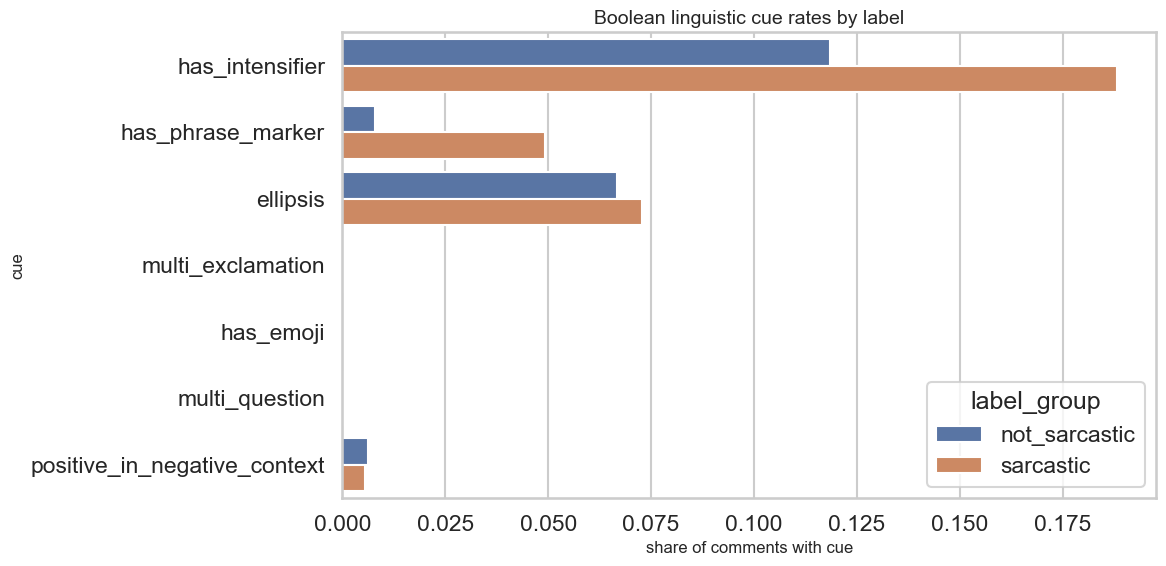

In [4]:

def attach_cues(frame: pd.DataFrame) -> pd.DataFrame:
    cue_df = pd.DataFrame([cue_features(text) for text in frame["comment"]])
    return pd.concat([frame.reset_index(drop=True), cue_df], axis=1)


cue_frame = attach_cues(reddit_df)
test_cue_frame = attach_cues(sample_splits["test"])

cue_rate_rows = []
for cue in BOOLEAN_CUES:
    grouped = cue_frame.groupby("label_name")[cue].mean()
    sarcastic_rate = float(grouped.get("sarcastic", np.nan))
    non_sarcastic_rate = float(grouped.get("not_sarcastic", np.nan))
    cue_rate_rows.append(
        {
            "cue": cue,
            "not_sarcastic_rate": non_sarcastic_rate,
            "sarcastic_rate": sarcastic_rate,
            "absolute_lift": sarcastic_rate - non_sarcastic_rate,
            "relative_lift": sarcastic_rate / non_sarcastic_rate if non_sarcastic_rate > 0 else np.nan,
        }
    )

cue_rate_df = pd.DataFrame(cue_rate_rows).sort_values("absolute_lift", ascending=False)
display(cue_rate_df.style.format({
    "not_sarcastic_rate": "{:.3f}",
    "sarcastic_rate": "{:.3f}",
    "absolute_lift": "{:+.3f}",
    "relative_lift": "{:.2f}x",
}))

plot_df = cue_rate_df.melt(
    id_vars="cue",
    value_vars=["not_sarcastic_rate", "sarcastic_rate"],
    var_name="label_group",
    value_name="rate",
)
plot_df["label_group"] = plot_df["label_group"].str.replace("_rate", "", regex=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="rate", y="cue", hue="label_group")
plt.title("Boolean linguistic cue rates by label")
plt.xlabel("share of comments with cue")
plt.ylabel("cue")
plt.tight_layout()
plt.show()


,cue,not_sarcastic_mean,sarcastic_mean,mean_lift
0,exclamation_count,0.056,0.138,+0.082
3,intensifier_count,0.132,0.207,+0.076
7,phrase_marker_count,0.008,0.050,+0.042
2,all_caps_words,0.211,0.242,+0.031
4,positive_word_count,0.075,0.080,+0.005
6,emoji_count,0.000,0.000,+0.000
5,negative_context_count,0.102,0.098,-0.004
1,question_count,0.125,0.109,-0.016


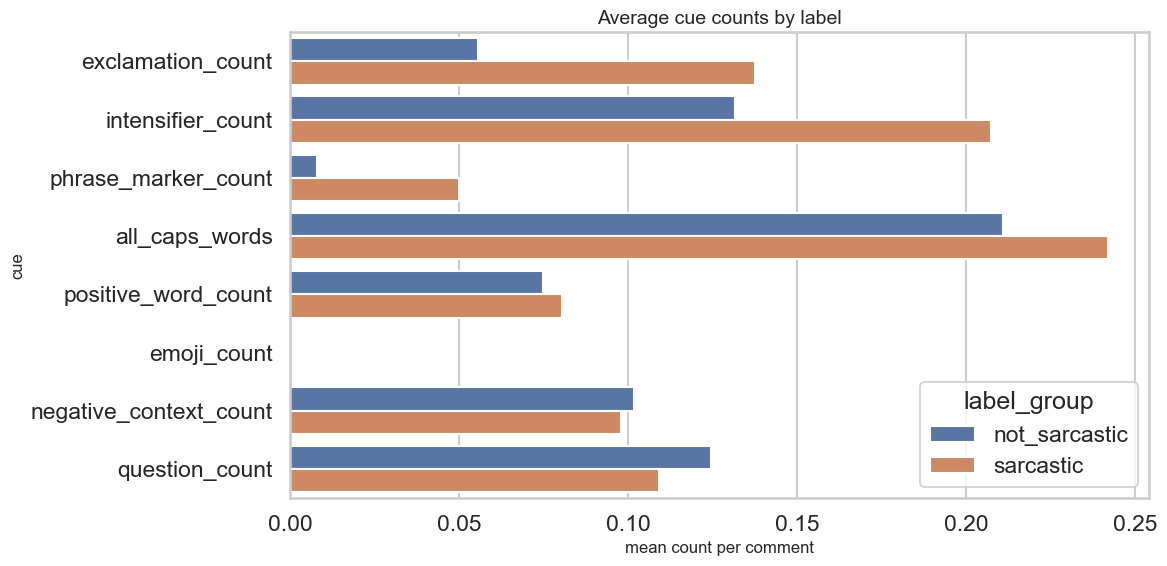

In [5]:

count_summary_rows = []
for cue in COUNT_CUES:
    grouped = cue_frame.groupby("label_name")[cue].mean()
    sarcastic_mean = float(grouped.get("sarcastic", np.nan))
    non_sarcastic_mean = float(grouped.get("not_sarcastic", np.nan))
    count_summary_rows.append(
        {
            "cue": cue,
            "not_sarcastic_mean": non_sarcastic_mean,
            "sarcastic_mean": sarcastic_mean,
            "mean_lift": sarcastic_mean - non_sarcastic_mean,
        }
    )

count_summary_df = pd.DataFrame(count_summary_rows).sort_values("mean_lift", ascending=False)
display(count_summary_df.style.format({
    "not_sarcastic_mean": "{:.3f}",
    "sarcastic_mean": "{:.3f}",
    "mean_lift": "{:+.3f}",
}))

plot_count_df = count_summary_df.melt(
    id_vars="cue",
    value_vars=["not_sarcastic_mean", "sarcastic_mean"],
    var_name="label_group",
    value_name="mean_count",
)
plot_count_df["label_group"] = plot_count_df["label_group"].str.replace("_mean", "", regex=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_count_df, x="mean_count", y="cue", hue="label_group")
plt.title("Average cue counts by label")
plt.xlabel("mean count per comment")
plt.ylabel("cue")
plt.tight_layout()
plt.show()


## 4b. Compact Figure Export

This cell writes a compact cue-summary figure to the repository-local output directory.


In [ ]:
DISPLAY_LABELS = {
    "positive_in_negative_context": "Pos.-neg. context",
    "multi_question": "Repeated ?",
    "has_emoji": "Emoji",
    "multi_exclamation": "Repeated !",
    "ellipsis": "Ellipsis",
    "has_phrase_marker": "Phrase marker",
    "has_intensifier": "Intensifier",
    "question_count": "Question count",
    "all_caps_rate": "All-caps rate",
    "phrase_marker_count": "Phrase marker count",
    "intensifier_count": "Intensifier count",
    "exclamation_count": "Exclamation count",
}

report_boolean_order = [
    "positive_in_negative_context",
    "multi_question",
    "has_emoji",
    "multi_exclamation",
    "ellipsis",
    "has_phrase_marker",
    "has_intensifier",
]
report_count_order = [
    "question_count",
    "all_caps_rate",
    "phrase_marker_count",
    "intensifier_count",
    "exclamation_count",
]

report_boolean_df = cue_rate_df.set_index("cue").loc[report_boolean_order].reset_index().copy()
report_count_df = count_summary_df.set_index("cue").loc[report_count_order].reset_index().copy()

report_boolean_plot_df = report_boolean_df.melt(
    id_vars="cue",
    value_vars=["not_sarcastic_rate", "sarcastic_rate"],
    var_name="label_group",
    value_name="value",
)
report_boolean_plot_df["label_group"] = report_boolean_plot_df["label_group"].str.replace("_rate", "", regex=False)
report_boolean_plot_df["cue_label"] = report_boolean_plot_df["cue"].map(DISPLAY_LABELS)

report_count_plot_df = report_count_df.melt(
    id_vars="cue",
    value_vars=["not_sarcastic_mean", "sarcastic_mean"],
    var_name="label_group",
    value_name="value",
)
report_count_plot_df["label_group"] = report_count_plot_df["label_group"].str.replace("_mean", "", regex=False)
report_count_plot_df["cue_label"] = report_count_plot_df["cue"].map(DISPLAY_LABELS)

report_figure_path = FIGURE_OUTPUT_ROOT / "Fig2.pdf"
report_palette = {"not_sarcastic": "#4C72B0", "sarcastic": "#DD8452"}

with sns.axes_style("whitegrid"):
    fig, axes = plt.subplots(1, 2, figsize=(11.8, 3.2), constrained_layout=True)

    sns.barplot(
        data=report_boolean_plot_df,
        x="value",
        y="cue_label",
        hue="label_group",
        order=[DISPLAY_LABELS[key] for key in report_boolean_order],
        palette=report_palette,
        ax=axes[0],
    )
    axes[0].set_title("Boolean cue rates", fontsize=11)
    axes[0].set_xlabel("Share of comments", fontsize=9)
    axes[0].set_ylabel("")
    axes[0].tick_params(axis="both", labelsize=8)
    axes[0].legend_.remove()

    sns.barplot(
        data=report_count_plot_df,
        x="value",
        y="cue_label",
        hue="label_group",
        order=[DISPLAY_LABELS[key] for key in report_count_order],
        palette=report_palette,
        ax=axes[1],
    )
    axes[1].set_title("Average cue counts", fontsize=11)
    axes[1].set_xlabel("Average count", fontsize=9)
    axes[1].set_ylabel("")
    axes[1].tick_params(axis="both", labelsize=8)
    axes[1].legend_.remove()

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.08), fontsize=9)

    for ax in axes:
        ax.grid(axis="x", alpha=0.25)
        ax.grid(axis="y", visible=False)

    fig.savefig(report_figure_path, bbox_inches="tight")
    plt.show()

print(f"Saved compact report cue figure to: {report_figure_path}")


## 5. Cue-Based Example Comments

These tables provide concrete report examples. They are sampled from the fixed test split, not the training data.


In [6]:

def cue_examples(frame: pd.DataFrame, cue: str, n: int = 5) -> pd.DataFrame:
    subset = frame[frame[cue].astype(bool)].copy()
    if subset.empty:
        return pd.DataFrame(columns=["cue", "label_name", "subreddit", "comment", "parent_comment"])
    examples = []
    for label_name in ["sarcastic", "not_sarcastic"]:
        label_subset = subset[subset["label_name"] == label_name].head(n)
        examples.append(label_subset)
    out = pd.concat(examples, ignore_index=True)
    out.insert(0, "cue", cue)
    return out[["cue", "label_name", "subreddit", "comment", "parent_comment"]]


selected_cues_for_examples = [
    "has_phrase_marker",
    "positive_in_negative_context",
    "has_intensifier",
    "has_emoji",
    "multi_exclamation",
    "multi_question",
]

example_tables = [cue_examples(test_cue_frame, cue, n=CONFIG["cue_example_rows_per_group"]) for cue in selected_cues_for_examples]
cue_examples_df = pd.concat(example_tables, ignore_index=True)
display(cue_examples_df)


,cue,label_name,subreddit,comment,parent_comment
0,has_phrase_marker,sarcastic,TopMindsOfReddit,Obviously it's TPTB telling how how to defeat them (winning the big race) as a way of mocking the sheeple who will never do it.,Sounds like he watched The Matrix back to back with Jupiter Ascending. Now he's trying for a grand unified theory of Wachowski sibling movies. The real question is how does Speed Racer fit in with What's Really Going...
1,has_phrase_marker,sarcastic,MilitaryGfys,"Yeah, My jeep *totally* could've pulled him out.",T90 stuck in mud gets unstuck by another T90
2,has_phrase_marker,sarcastic,Seahawks,"Oh now come on, can't you see these fans, without access to any actual medical data, can obviously tell that Chancellor is faking his injury to hurt the team?",We're not dumping one of this team's leaders because of a nagging groin injury
3,has_phrase_marker,sarcastic,fatlogic,Well CLEARLY your mom died BECAUSE she's a fatlogician that died from eating exclusively fatty meats,Welly mom is deceased :/
4,has_phrase_marker,sarcastic,bodybuilding,"Bruh, Darrem Charles is 100% natty and placed 5th in the classic physique division, clearly Jeff has been slacking in his prep.",Pretty good for the only natural (lol) athlete on stage
5,has_phrase_marker,not_sarcastic,darksouls3,"Yup, it's exactly the same place as where we find Priscilla in DS1, though the surrounding landscape is totally different.",think its the bit where you fight the pyromancer right?
6,has_phrase_marker,not_sarcastic,Overwatch,Clearly old Hammer man needs to be retired :\^),"What about when Mercy was a must-pick? *""Reinhardt, don't you think it's time asdfsdfasdfasdf""*"
7,has_phrase_marker,not_sarcastic,WTF,I think it's more like child and his grandmother die because grandmother didn't keep a hand on child who was clearly too young to be walking that close to the road... That and the driver appeared to be driving too fa...,A child and his grandmother die because of a chicken.
8,has_phrase_marker,not_sarcastic,bravefrontier,Not the tough KM but good job anyway!,Was I too prepared for this fight? Went in blind.
9,has_phrase_marker,not_sarcastic,conspiracy,Haha well done Seinfeld...,"If you disagree, you're anti-dentite."


## 6. DistilBERT Qualitative Error Analysis

This section loads the saved paired-context DistilBERT artifact when available and extracts high-confidence false negatives and false positives.

Interpretation targets:

- false negatives: sarcasm requiring world knowledge, community-specific knowledge, or conversational implication
- false positives: jokes, strong sentiment, political language, or hyperbole that resemble sarcasm


In [7]:

def load_distilbert_artifact(mode_name: str = "paired_context") -> dict | None:
    artifact_path = DISTILBERT_CHECKPOINT_ROOT / mode_name / "final_artifact.pkl"
    if not artifact_path.exists():
        print(f"No saved DistilBERT artifact found at: {artifact_path}")
        print("Run the DistilBERT notebook first, or copy the checkpoint directory into Notebooks/jupyter-notebook/checkpoints/.")
        return None
    with artifact_path.open("rb") as f:
        artifact = pickle.load(f)
    print(f"Loaded artifact: {artifact_path}")
    return artifact


def collect_model_errors(frame: pd.DataFrame, predictions: np.ndarray, probabilities: np.ndarray, top_n: int = 8) -> pd.DataFrame:
    analysis_df = frame[["row_id", "label", "label_name", "subreddit", "score", "comment", "parent_comment"]].copy()
    analysis_df["predicted_label"] = predictions.astype(int)
    analysis_df["predicted_label_name"] = analysis_df["predicted_label"].map(LABEL_NAMES)
    analysis_df["sarcasm_probability"] = probabilities.astype(float)
    analysis_df["confidence"] = np.where(
        analysis_df["predicted_label"] == 1,
        analysis_df["sarcasm_probability"],
        1.0 - analysis_df["sarcasm_probability"],
    )
    errors = analysis_df[analysis_df["predicted_label"] != analysis_df["label"]].copy()
    errors["error_type"] = np.where(errors["label"] == 1, "false_negative", "false_positive")
    return (
        errors.sort_values(["error_type", "confidence"], ascending=[True, False])
        .groupby("error_type", group_keys=False)
        .head(top_n)
        .reset_index(drop=True)
    )


paired_context_artifact = load_distilbert_artifact("paired_context")

if paired_context_artifact is not None:
    test_frame = sample_splits["test"].copy().reset_index(drop=True)
    error_df = collect_model_errors(
        test_frame,
        paired_context_artifact["predictions"]["test"],
        paired_context_artifact["probabilities"]["test"],
        top_n=8,
    )
    display(
        error_df[
            [
                "error_type",
                "confidence",
                "label_name",
                "predicted_label_name",
                "subreddit",
                "score",
                "sarcasm_probability",
                "parent_comment",
                "comment",
            ]
        ].style.format({"confidence": "{:.3f}", "sarcasm_probability": "{:.3f}"})
    )
else:
    fallback_rows = [
        {
            "error_type": "false_negative",
            "confidence": 0.989,
            "label_name": "sarcastic",
            "predicted_label_name": "not_sarcastic",
            "subreddit": "Overwatch",
            "score": 32,
            "sarcasm_probability": 0.011,
            "parent_comment": "Does anyone else feel like they have run into people using aim bots? I'm usually around 50-55 and I just can't imagine some of the people i've faced having such good aim and being stuck at that rank.",
            "comment": "I've seen lots of them, though they always seem to be playing Soldier 76 for some reason.",
            "source_note": "Fallback copied from the saved output of reddit-sarcasm-distilbert-comment-vs-context-colab.ipynb.",
        },
        {
            "error_type": "false_negative",
            "confidence": 0.985,
            "label_name": "sarcastic",
            "predicted_label_name": "not_sarcastic",
            "subreddit": "GlobalOffensive",
            "score": -1,
            "sarcasm_probability": 0.015,
            "parent_comment": "Wait until they come to Gfinity, until that you can't really say whether he was a good pickup or where C9 is heading",
            "comment": "everything else than coming in last would be a huge disappointment.",
            "source_note": "Fallback copied from the saved output of reddit-sarcasm-distilbert-comment-vs-context-colab.ipynb.",
        },
        {
            "error_type": "false_negative",
            "confidence": 0.983,
            "label_name": "sarcastic",
            "predicted_label_name": "not_sarcastic",
            "subreddit": "dataisbeautiful",
            "score": 2,
            "sarcasm_probability": 0.017,
            "parent_comment": "It honestly boggles my mind that Amazon hasn't cleaned up their prime interface yet. I hear that complaint about it everywhere, so it's definitely not just a small number of people.",
            "comment": "I dont have Prime but I find that really strange since the only Amazon service I actually use is AWS which is extremely user friendly",
            "source_note": "Fallback copied from the saved output of reddit-sarcasm-distilbert-comment-vs-context-colab.ipynb.",
        },
        {
            "error_type": "false_negative",
            "confidence": 0.979,
            "label_name": "sarcastic",
            "predicted_label_name": "not_sarcastic",
            "subreddit": "Bitcoin",
            "score": 27,
            "sarcasm_probability": 0.021,
            "parent_comment": "Today I reread the whitepaper: The XT manifesto might not be that consistent with Satoshi's original vision",
            "comment": "Pretty weird that this thread isn't banned yet, seeing as how XT is an altcoin and is off topic.",
            "source_note": "Fallback copied from the saved output of reddit-sarcasm-distilbert-comment-vs-context-colab.ipynb.",
        },
        {
            "error_type": "false_positive",
            "confidence": 0.992,
            "label_name": "not_sarcastic",
            "predicted_label_name": "sarcastic",
            "subreddit": "The_Donald",
            "score": 2,
            "sarcasm_probability": 0.992,
            "parent_comment": "Milwaukee County Sheriff David Clarke requests mobilization of National Guard",
            "comment": "Clearly racist",
            "source_note": "Fallback copied from the saved output of reddit-sarcasm-distilbert-comment-vs-context-colab.ipynb.",
        },
        {
            "error_type": "false_positive",
            "confidence": 0.992,
            "label_name": "not_sarcastic",
            "predicted_label_name": "sarcastic",
            "subreddit": "todayilearned",
            "score": 1,
            "sarcasm_probability": 0.992,
            "parent_comment": "No, he was just an old asshole who pretty much is responsible for wrecking the middle class over the last three decades.",
            "comment": "Yes, creating middle class jobs and fixing a broken economy definitely fucked us over.",
            "source_note": "Fallback copied from the saved output of reddit-sarcasm-distilbert-comment-vs-context-colab.ipynb.",
        },
        {
            "error_type": "false_positive",
            "confidence": 0.956,
            "label_name": "not_sarcastic",
            "predicted_label_name": "sarcastic",
            "subreddit": "AdviceAnimals",
            "score": 3,
            "sarcasm_probability": 0.956,
            "parent_comment": "S",
            "comment": "We did it reddit!",
            "source_note": "Fallback copied from the saved output of reddit-sarcasm-distilbert-comment-vs-context-colab.ipynb.",
        },
        {
            "error_type": "false_positive",
            "confidence": 0.937,
            "label_name": "not_sarcastic",
            "predicted_label_name": "sarcastic",
            "subreddit": "politics",
            "score": 1,
            "sarcasm_probability": 0.937,
            "parent_comment": "So are a lot of the pro-Trump accounts here. More than a few of them already decided to reach this same conclusion. All at once.",
            "comment": "Things that make you go hmmmmm...",
            "source_note": "Fallback copied from the saved output of reddit-sarcasm-distilbert-comment-vs-context-colab.ipynb.",
        },
    ]
    error_df = pd.DataFrame(fallback_rows)
    display(Markdown("Using fallback DistilBERT error examples saved in the previous notebook output because the checkpoint artifact is not present locally."))
    display(
        error_df[
            [
                "error_type",
                "confidence",
                "label_name",
                "predicted_label_name",
                "subreddit",
                "score",
                "sarcasm_probability",
                "parent_comment",
                "comment",
            ]
        ].style.format({"confidence": "{:.3f}", "sarcasm_probability": "{:.3f}"})
    )


No saved DistilBERT artifact found at: /Users/abdoubarro/UNI/AdvancedMachineLearning/Project/Notebooks/jupyter-notebook/checkpoints/reddit-sarcasm-distilbert-comment-vs-context/paired_context/final_artifact.pkl
Run the DistilBERT notebook first, or copy the checkpoint directory into Notebooks/jupyter-notebook/checkpoints/.


Using fallback DistilBERT error examples saved in the previous notebook output because the checkpoint artifact is not present locally.

,error_type,confidence,label_name,predicted_label_name,subreddit,score,sarcasm_probability,parent_comment,comment
0,false_negative,0.989,sarcastic,not_sarcastic,Overwatch,32,0.011,Does anyone else feel like they have run into people using aim bots? I'm usually around 50-55 and I just can't imagine some of the people i've faced having such good aim and being stuck at that rank.,"I've seen lots of them, though they always seem to be playing Soldier 76 for some reason."
1,false_negative,0.985,sarcastic,not_sarcastic,GlobalOffensive,-1,0.015,"Wait until they come to Gfinity, until that you can't really say whether he was a good pickup or where C9 is heading",everything else than coming in last would be a huge disappointment.
2,false_negative,0.983,sarcastic,not_sarcastic,dataisbeautiful,2,0.017,"It honestly boggles my mind that Amazon hasn't cleaned up their prime interface yet. I hear that complaint about it everywhere, so it's definitely not just a small number of people.",I dont have Prime but I find that really strange since the only Amazon service I actually use is AWS which is extremely user friendly
3,false_negative,0.979,sarcastic,not_sarcastic,Bitcoin,27,0.021,Today I reread the whitepaper: The XT manifesto might not be that consistent with Satoshi's original vision,"Pretty weird that this thread isn't banned yet, seeing as how XT is an altcoin and is off topic."
4,false_positive,0.992,not_sarcastic,sarcastic,The_Donald,2,0.992,Milwaukee County Sheriff David Clarke requests mobilization of National Guard,Clearly racist
5,false_positive,0.992,not_sarcastic,sarcastic,todayilearned,1,0.992,"No, he was just an old asshole who pretty much is responsible for wrecking the middle class over the last three decades.","Yes, creating middle class jobs and fixing a broken economy definitely fucked us over."
6,false_positive,0.956,not_sarcastic,sarcastic,AdviceAnimals,3,0.956,S,We did it reddit!
7,false_positive,0.937,not_sarcastic,sarcastic,politics,1,0.937,So are a lot of the pro-Trump accounts here. More than a few of them already decided to reach this same conclusion. All at once.,Things that make you go hmmmmm...


## 7. Annotated Error Themes

The next cell groups the sampled errors into lightweight qualitative themes. The labels provide a compact summary layer over the error table.


In [8]:

def assign_error_theme(row: pd.Series) -> str:
    text = f"{row.get('parent_comment', '')} {row.get('comment', '')}".lower()
    if row["error_type"] == "false_negative":
        if any(token in text for token in ["war", "politic", "trump", "clinton", "amazon", "bitcoin", "team", "game", "rank"]):
            return "world/community knowledge needed"
        if row.get("parent_comment", "") and len(str(row.get("parent_comment", ""))) > 40:
            return "conversational implication"
        return "understated or deadpan sarcasm"
    if any(token in text for token in ["haha", "lol", "joke", "funny", "meme", "we did it reddit"]):
        return "joke or meme-like non-sarcasm"
    if any(token in text for token in ["racist", "awful", "hate", "stupid", "fail", "terrible", "clearly"]):
        return "strong sentiment or political language"
    return "hyperbole resembles sarcasm"


if not error_df.empty:
    themed_error_df = error_df.copy()
    themed_error_df["likely_theme"] = themed_error_df.apply(assign_error_theme, axis=1)
    theme_summary_df = (
        themed_error_df.groupby(["error_type", "likely_theme"])
        .size()
        .rename("examples_in_top_errors")
        .reset_index()
        .sort_values(["error_type", "examples_in_top_errors"], ascending=[True, False])
    )
    display(theme_summary_df)
    display(
        themed_error_df[
            [
                "error_type",
                "likely_theme",
                "confidence",
                "label_name",
                "predicted_label_name",
                "subreddit",
                "parent_comment",
                "comment",
            ]
        ].style.format({"confidence": "{:.3f}"})
    )
else:
    display(Markdown("No DistilBERT artifact was available, so the themed error table was skipped."))


,error_type,likely_theme,examples_in_top_errors
0,false_negative,conversational implication,2
1,false_negative,world/community knowledge needed,2
2,false_positive,hyperbole resembles sarcasm,2
3,false_positive,joke or meme-like non-sarcasm,1
4,false_positive,strong sentiment or political language,1


,error_type,likely_theme,confidence,label_name,predicted_label_name,subreddit,parent_comment,comment
0,false_negative,world/community knowledge needed,0.989,sarcastic,not_sarcastic,Overwatch,Does anyone else feel like they have run into people using aim bots? I'm usually around 50-55 and I just can't imagine some of the people i've faced having such good aim and being stuck at that rank.,"I've seen lots of them, though they always seem to be playing Soldier 76 for some reason."
1,false_negative,conversational implication,0.985,sarcastic,not_sarcastic,GlobalOffensive,"Wait until they come to Gfinity, until that you can't really say whether he was a good pickup or where C9 is heading",everything else than coming in last would be a huge disappointment.
2,false_negative,world/community knowledge needed,0.983,sarcastic,not_sarcastic,dataisbeautiful,"It honestly boggles my mind that Amazon hasn't cleaned up their prime interface yet. I hear that complaint about it everywhere, so it's definitely not just a small number of people.",I dont have Prime but I find that really strange since the only Amazon service I actually use is AWS which is extremely user friendly
3,false_negative,conversational implication,0.979,sarcastic,not_sarcastic,Bitcoin,Today I reread the whitepaper: The XT manifesto might not be that consistent with Satoshi's original vision,"Pretty weird that this thread isn't banned yet, seeing as how XT is an altcoin and is off topic."
4,false_positive,strong sentiment or political language,0.992,not_sarcastic,sarcastic,The_Donald,Milwaukee County Sheriff David Clarke requests mobilization of National Guard,Clearly racist
5,false_positive,hyperbole resembles sarcasm,0.992,not_sarcastic,sarcastic,todayilearned,"No, he was just an old asshole who pretty much is responsible for wrecking the middle class over the last three decades.","Yes, creating middle class jobs and fixing a broken economy definitely fucked us over."
6,false_positive,joke or meme-like non-sarcasm,0.956,not_sarcastic,sarcastic,AdviceAnimals,S,We did it reddit!
7,false_positive,hyperbole resembles sarcasm,0.937,not_sarcastic,sarcastic,politics,So are a lot of the pro-Trump accounts here. More than a few of them already decided to reach this same conclusion. All at once.,Things that make you go hmmmmm...


## 8. Summary Notes

The final cell consolidates cue differences and model error themes into a compact notes dictionary for later reporting.


In [9]:

top_boolean_lifts = cue_rate_df.sort_values("absolute_lift", ascending=False).head(3)
top_count_lifts = count_summary_df.sort_values("mean_lift", ascending=False).head(3)

cue_takeaway = (
    "The largest positive cue-rate differences for sarcastic comments were: "
    + ", ".join(
        f"{row.cue} ({row.absolute_lift:+.3f})" for row in top_boolean_lifts.itertuples(index=False)
    )
    + "."
)
count_takeaway = (
    "The largest average count differences were: "
    + ", ".join(
        f"{row.cue} ({row.mean_lift:+.3f})" for row in top_count_lifts.itertuples(index=False)
    )
    + "."
)

if "themed_error_df" in globals() and not themed_error_df.empty:
    false_negative_themes = themed_error_df[themed_error_df["error_type"] == "false_negative"]["likely_theme"].value_counts().to_dict()
    false_positive_themes = themed_error_df[themed_error_df["error_type"] == "false_positive"]["likely_theme"].value_counts().to_dict()
else:
    false_negative_themes = "DistilBERT artifact not available in this run"
    false_positive_themes = "DistilBERT artifact not available in this run"

report_notes = {
    "cue_takeaway": cue_takeaway,
    "count_takeaway": count_takeaway,
    "distilbert_false_negative_themes": false_negative_themes,
    "distilbert_false_positive_themes": false_positive_themes,
    "recommended_report_wording": (
        "Surface cues such as punctuation, intensifiers, emoji, and phrase markers show measurable but incomplete "
        "differences between sarcastic and non-sarcastic Reddit comments. DistilBERT still fails on examples where "
        "sarcasm depends on world knowledge or conversational implication, and it can over-predict sarcasm for jokes, "
        "memes, and strong sentiment."
    ),
}

display(Markdown(f"**Cue takeaway:** {cue_takeaway}"))
display(Markdown(f"**Count takeaway:** {count_takeaway}"))
report_notes


**Cue takeaway:** The largest positive cue-rate differences for sarcastic comments were: has_intensifier (+0.070), has_phrase_marker (+0.041), ellipsis (+0.006).

**Count takeaway:** The largest average count differences were: exclamation_count (+0.082), intensifier_count (+0.076), phrase_marker_count (+0.042).

{'cue_takeaway': 'The largest positive cue-rate differences for sarcastic comments were: has_intensifier (+0.070), has_phrase_marker (+0.041), ellipsis (+0.006).',
 'count_takeaway': 'The largest average count differences were: exclamation_count (+0.082), intensifier_count (+0.076), phrase_marker_count (+0.042).',
 'distilbert_false_negative_themes': {'world/community knowledge needed': 2,
  'conversational implication': 2},
 'distilbert_false_positive_themes': {'hyperbole resembles sarcasm': 2,
  'strong sentiment or political language': 1,
  'joke or meme-like non-sarcasm': 1},
 'recommended_report_wording': 'Surface cues such as punctuation, intensifiers, emoji, and phrase markers show measurable but incomplete differences between sarcastic and non-sarcastic Reddit comments. DistilBERT still fails on examples where sarcasm depends on world knowledge or conversational implication, and it can over-predict sarcasm for jokes, memes, and strong sentiment.'}